# Consumo de Água no Brasil: análise exploratória, KPIs e qualidade de dados

**Curso:** Sistemas de Informação · **Disciplina:** Linguagens de Programação
**Autor:** Erick Ribeiro

**Tecnologias:** Python · Pandas · NumPy · Matplotlib · Seaborn · SQLAlchemy/SQLite · Requests (API do IBGE)

---

### Roteiro
1. Introdução ao problema
2. Explicação da base de dados
3. Leitura dos dados
4. Limpeza e preparação
5. Engenharia de atributos
6. Persistência e integração (SQLite + API do IBGE)
7. Análise exploratória
8. KPIs
9. Gráficos
10. Interpretação dos resultados
11. Conclusão

## 1. Introdução ao problema

A água é um recurso estratégico, e sua gestão no Brasil enfrenta três desafios simultâneos:

- **Demanda**: consumo residencial, comercial, industrial, agrícola e público disputando o mesmo recurso;
- **Perdas**: segundo o SNIS, o país perde cerca de 40% da água tratada na distribuição;
- **Disponibilidade**: reservatórios dependem do regime de chuvas e são afetados por secas e temperatura.

**Objetivo:** analisar uma base de consumo mensal de água por estado e setor (2015–2024) para responder:

1. Onde e em que setor se concentra o consumo?
2. Qual o tamanho do desperdício e onde ele é mais grave?
3. Como estão os reservatórios e a frequência de alertas?
4. Existe tendência ou sazonalidade? O clima (chuva e temperatura) explica o consumo e os reservatórios?
5. Os dados são **consistentes** o suficiente para apoiar decisões?

## 2. Explicação da base de dados

Arquivo: `dados/simulacao_consumo_agua_brasil.csv`. Base **simulada**, fornecida pelo professor. Cada linha é um registro
mensal de um estado (UF) e um setor de consumo.

| Coluna | Tipo | Descrição |
|---|---|---|
| `ano`, `mes`, `data` | inteiro / data | Período de referência (primeiro dia do mês) |
| `regiao`, `uf` | texto | Região geográfica e sigla do estado |
| `setor_consumo` | texto | Residencial, Comercial, Industrial, Agrícola ou Público |
| `consumo_milhoes_litros` | decimal | Volume consumido no mês (milhões de litros) |
| `desperdicio_percentual` | decimal | % do volume perdido (vazamentos, perdas) |
| `reservatorios_percentual` | decimal | Nível dos reservatórios (% da capacidade) |
| `chuva_mm` | decimal | Precipitação acumulada no mês (mm) |
| `temperatura_media` | decimal | Temperatura média do mês (°C) |
| `populacao` | inteiro | População atendida |
| `consumo_per_capita` | decimal | Consumo por habitante (L/hab/dia) |
| `nivel_alerta` | texto | Baixo, Médio, Alto ou Crítico |

Fontes complementares integradas no projeto:
- **API de Localidades do IBGE**: nomes oficiais e regiões das 27 UFs;
- **API de Malhas do IBGE**: GeoJSON das UFs (mapa do dashboard);
- **API SIDRA/IBGE (tabela 6579)**: estimativa oficial de população por UF (2021).

## 3. Leitura dos dados

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Permite importar os módulos do projeto (pasta utils/) a partir de notebooks/.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from utils import api_ibge, banco, dados, estilo  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
estilo.aplicar_estilo_mpl()
# Tema dos gráficos: claro por padrão. Com TEMA_GRAFICOS=dark, as imagens vão para imagens/dark/
# (versão usada pelo modo escuro da página do projeto).
PASTA_IMG = RAIZ / "imagens" / ("dark" if estilo.MODO == "dark" else "")
PASTA_IMG.mkdir(parents=True, exist_ok=True)


def salvar(fig, nome):
    """Salva a figura em imagens/ (usada no README e no GitHub Pages)."""
    fig.savefig(PASTA_IMG / f"{nome}.png")

In [2]:
bruto = pd.read_csv(RAIZ / "dados" / "simulacao_consumo_agua_brasil.csv", encoding="utf-8")
print(f"Dimensões: {bruto.shape[0]:,} linhas × {bruto.shape[1]} colunas")
bruto.head()

Dimensões: 4,440 linhas × 14 colunas


,ano,mes,data,regiao,uf,setor_consumo,consumo_milhoes_litros,desperdicio_percentual,reservatorios_percentual,chuva_mm,temperatura_media,populacao,consumo_per_capita,nivel_alerta
0,2015,1,2015-01-01,Norte,AM,Público,6.64,18.56,52.75,316.70,26.10,2440046,244.63,Médio
1,2015,1,2015-01-01,Norte,PA,Agrícola,19.81,9.63,21.75,190.00,24.40,2340035,143.77,Crítico
2,2015,1,2015-01-01,Norte,PA,Agrícola,20.54,28.69,25.44,163.50,27.40,5917187,318.44,Baixo
3,2015,1,2015-01-01,Norte,RO,Residencial,30.18,15.75,54.90,30.90,22.70,1950109,313.67,Baixo
4,2015,1,2015-01-01,Norte,TO,Comercial,34.61,17.66,50.44,136.60,25.20,3246728,380.89,Alto


In [3]:
bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ano                       4440 non-null   int64  
 1   mes                       4440 non-null   int64  
 2   data                      4440 non-null   str    
 3   regiao                    4440 non-null   str    
 4   uf                        4440 non-null   str    
 5   setor_consumo             4440 non-null   str    
 6   consumo_milhoes_litros    4440 non-null   float64
 7   desperdicio_percentual    4440 non-null   float64
 8   reservatorios_percentual  4440 non-null   float64
 9   chuva_mm                  4440 non-null   float64
 10  temperatura_media         4440 non-null   float64
 11  populacao                 4440 non-null   int64  
 12  consumo_per_capita        4440 non-null   float64
 13  nivel_alerta              4440 non-null   str    
dtypes: float64(6), int6

In [4]:
# Cobertura: quantos registros por mês, quantas UFs e quantas séries por UF
print("Período:", bruto["data"].min(), "a", bruto["data"].max())
print("Registros por mês:", bruto.groupby("data").size().unique())
print("UFs presentes:", bruto["uf"].nunique(), "de 27")
bruto.groupby(["regiao", "uf"]).size().div(120).rename("séries (UF × setor) por mês").to_frame().T

Período: 2015-01-01 a 2024-12-01
Registros por mês: [37]
UFs presentes: 20 de 27


regiao                      Centro-Oeste                Nordeste            \
uf                                    DF   GO   MS   MT       BA   CE   MA   
séries (UF × setor) por mês         1.00 2.00 1.00 1.00     2.00 2.00 1.00   

regiao                                Norte                Sudeste            \
uf                            PB   PE    AM   PA   RO   TO      ES   MG   RJ   
séries (UF × setor) por mês 1.00 2.00  1.00 2.00 1.00 1.00    3.00 3.00 4.00   

regiao                            Sul            
uf                            SP   PR   RS   SC  
séries (UF × setor) por mês 3.00 2.00 2.00 2.00

**Observações iniciais:** 4.440 registros de jan/2015 a dez/2024, sempre **37 registros por mês**. São 20 das 27 UFs, e
alguns estados têm mais de uma série por mês (RJ tem 4; SP, MG e ES têm 3). Isso vai pesar nas somas por região.

## 4. Limpeza e preparação

In [5]:
df = bruto.copy()

# 4.1 Padronização de textos
for col in ["regiao", "setor_consumo", "nivel_alerta"]:
    df[col] = df[col].str.strip().str.title()
df["uf"] = df["uf"].str.strip().str.upper()

# 4.2 Conversão de tipos
num = ["consumo_milhoes_litros", "desperdicio_percentual", "reservatorios_percentual", "chuva_mm",
       "temperatura_media", "populacao", "consumo_per_capita"]
df[num] = df[num].apply(pd.to_numeric, errors="coerce")
df["data"] = pd.to_datetime(df["data"], errors="coerce")

# 4.3 Valores ausentes e duplicatas
print("Nulos por coluna:", df.isna().sum().sum())
print("Linhas duplicadas:", df.duplicated().sum())
df = df.dropna().drop_duplicates()

Nulos por coluna: 0
Linhas duplicadas: 0


In [6]:
# 4.4 Validação de domínio: cada regra deve ter 0 violações
regras = {
    "percentuais entre 0 e 100": ~df["desperdicio_percentual"].between(0, 100) | ~df["reservatorios_percentual"].between(0, 100),
    "consumo, chuva e população positivos": (df["consumo_milhoes_litros"] < 0) | (df["chuva_mm"] < 0) | (df["populacao"] <= 0),
    "mês entre 1 e 12": ~df["mes"].between(1, 12),
    "temperatura plausível (-10 a 50 °C)": ~df["temperatura_media"].between(-10, 50),
    "data coerente com ano/mês": (df["data"].dt.year != df["ano"]) | (df["data"].dt.month != df["mes"]),
}
validacao = pd.Series({k: int(v.sum()) for k, v in regras.items()}, name="violações").to_frame()
df = df[~pd.concat(regras.values(), axis=1).any(axis=1)]
validacao

,violações
percentuais entre 0 e 100,0
"consumo, chuva e população positivos",0
mês entre 1 e 12,0
temperatura plausível (-10 a 50 °C),0
data coerente com ano/mês,0


In [7]:
# 4.5 Categorias ordenadas: garantem a ordem correta em tabelas e gráficos
df["regiao"] = pd.Categorical(df["regiao"], categories=dados.ORDEM_REGIOES, ordered=True)
df["setor_consumo"] = pd.Categorical(df["setor_consumo"], categories=dados.ORDEM_SETORES, ordered=True)
df["nivel_alerta"] = pd.Categorical(df["nivel_alerta"], categories=dados.ORDEM_ALERTA, ordered=True)
print("Categorias inválidas (viraram NaN):", df[["regiao", "setor_consumo", "nivel_alerta"]].isna().sum().sum())
print("Linhas finais:", len(df))

Categorias inválidas (viraram NaN): 0
Linhas finais: 4440


**Resultado:** a base original já estava íntegra, sem nulos, duplicatas ou valores fora do domínio. As validações
continuam no pipeline (`utils/dados.py`) para proteger o dashboard contra bases enviadas por **upload**.

## 5. Engenharia de atributos

In [8]:
estacao = {12: "Verão", 1: "Verão", 2: "Verão", 3: "Outono", 4: "Outono", 5: "Outono",
           6: "Inverno", 7: "Inverno", 8: "Inverno", 9: "Primavera", 10: "Primavera", 11: "Primavera"}

df["volume_desperdicado_ml"] = df["consumo_milhoes_litros"] * df["desperdicio_percentual"] / 100
df["consumo_efetivo_ml"] = df["consumo_milhoes_litros"] - df["volume_desperdicado_ml"]
df["trimestre"] = df["data"].dt.quarter
df["estacao"] = pd.Categorical(df["mes"].map(estacao), categories=dados.ORDEM_ESTACOES, ordered=True)
df["periodo_chuvoso"] = df["mes"].isin([10, 11, 12, 1, 2, 3])
df["faixa_reservatorio"] = pd.cut(df["reservatorios_percentual"], bins=[0, 30, 50, 70, 100.01],
                                  labels=dados.ORDEM_FAIXA_RESERVATORIO, right=False)
df["score_alerta"] = df["nivel_alerta"].cat.codes + 1
df["alerta_elevado"] = df["nivel_alerta"].isin(["Alto", "Crítico"])
df["reservatorio_critico"] = df["reservatorios_percentual"] < 30

q1, q3 = df["chuva_mm"].quantile([0.25, 0.75])
df["chuva_outlier"] = df["chuva_mm"] > q3 + 1.5 * (q3 - q1)

# Per capita recalculado: consumo (L) ÷ população ÷ dias do mês → usado na auditoria
df["per_capita_recalculado"] = df["consumo_milhoes_litros"] * 1e6 / df["populacao"] / df["data"].dt.days_in_month

print(f"Outliers de chuva (IQR): {df['chuva_outlier'].sum()} registros, mantidos e apenas sinalizados")
df[["data", "uf", "consumo_milhoes_litros", "desperdicio_percentual", "volume_desperdicado_ml", "estacao",
    "faixa_reservatorio", "score_alerta", "alerta_elevado"]].head()

Outliers de chuva (IQR): 117 registros, mantidos e apenas sinalizados


,data,uf,consumo_milhoes_litros,desperdicio_percentual,volume_desperdicado_ml,estacao,faixa_reservatorio,score_alerta,alerta_elevado
0,2015-01-01,AM,6.64,18.56,1.23,Verão,Moderado (50–70%),2,False
1,2015-01-01,PA,19.81,9.63,1.91,Verão,Crítico (<30%),4,True
2,2015-01-01,PA,20.54,28.69,5.89,Verão,Crítico (<30%),1,False
3,2015-01-01,RO,30.18,15.75,4.75,Verão,Moderado (50–70%),1,False
4,2015-01-01,TO,34.61,17.66,6.11,Verão,Moderado (50–70%),3,True


In [9]:
# O mesmo pipeline está empacotado em utils/dados.py e é usado pelo dashboard.
# Conferência: o resultado do notebook é idêntico ao do módulo.
pipeline, relatorio = dados.preparar()
numericas = ["consumo_milhoes_litros", "volume_desperdicado_ml", "consumo_efetivo_ml", "score_alerta"]
categoricas = ["faixa_reservatorio", "estacao", "nivel_alerta"]
iguais = (np.allclose(df[numericas].to_numpy(float), pipeline[numericas].to_numpy(float), atol=1e-3)  # módulo arredonda em 3 casas
          and df[categoricas].reset_index(drop=True).astype(str).equals(pipeline[categoricas].astype(str)))
print("Notebook e utils/dados.py produzem o mesmo resultado:", iguais)

Notebook e utils/dados.py produzem o mesmo resultado: True


## 6. Persistência e integração (SQLite + API do IBGE)

A base tratada é gravada em **SQLite** com **SQLAlchemy ORM**, num modelo relacional em estrela:

```
regioes 1──N estados 1──N medicoes N──1 setores
                             └──N──1 niveis_alerta
```

A tabela `estados` é preenchida com dados obtidos via **Requests** na API do IBGE (código, nome oficial, região e
população). Antes de gravar, o pipeline confere se a região de cada UF no CSV bate com a oficial.

In [10]:
ibge, info = api_ibge.dados_ibge()
print("Origem dos dados do IBGE:", info)
ibge.head()

Origem dos dados do IBGE: {'estados': 'cache', 'populacao': 'cache', 'consultado_em': '08/10/2026 14:13'}


,codigo_ibge,uf,nome_uf,regiao_ibge,populacao_ibge
0,12,AC,Acre,Norte,906876
1,27,AL,Alagoas,Nordeste,3365351
2,13,AM,Amazonas,Norte,4269995
3,16,AP,Amapá,Norte,877613
4,29,BA,Bahia,Nordeste,14985284


In [11]:
contagens = banco.criar_banco()
print("Registros por tabela:", contagens)

# Consulta com JOINs no modelo relacional
banco.executar_sql('''
SELECT r.nome AS regiao, COUNT(DISTINCT e.id) AS ufs, COUNT(*) AS registros,
       ROUND(SUM(m.consumo_milhoes_litros), 0) AS consumo_mi_l
FROM medicoes m
JOIN estados e ON e.id = m.estado_id
JOIN regioes r ON r.id = e.regiao_id
GROUP BY r.nome ORDER BY consumo_mi_l DESC
''')

Registros por tabela:

 {'regioes': 5, 'estados': 27, 'setores': 5, 'niveis_alerta': 4, 'medicoes': 4440}


,regiao,ufs,registros,consumo_mi_l
0,Sudeste,4,1560,"32,498.00"
1,Nordeste,5,960,"20,253.00"
2,Sul,3,720,"15,146.00"
3,Centro-Oeste,4,600,"12,372.00"
4,Norte,4,600,"12,298.00"


In [12]:
# UFs oficiais que não aparecem na base (LEFT JOIN)
banco.executar_sql('''
SELECT e.sigla, e.nome FROM estados e
LEFT JOIN medicoes m ON m.estado_id = e.id
WHERE m.id IS NULL ORDER BY e.sigla
''').T

,0,1,2,3,4,5,6
sigla,AC,AL,AP,PI,RN,RR,SE
nome,Acre,Alagoas,Amapá,Piauí,Rio Grande do Norte,Roraima,Sergipe


## 7. Análise exploratória

### 7.1 Estatísticas descritivas

In [13]:
desc = df[num].describe().T
desc["assimetria"] = df[num].skew()
desc["curtose"] = df[num].kurt()
desc

,count,mean,std,min,25%,50%,75%,max,assimetria,curtose
consumo_milhoes_litros,"4,440.00",20.85,10.93,2.00,11.24,20.76,30.40,39.99,0.02,-1.19
desperdicio_percentual,"4,440.00",30.19,14.31,5.00,18.02,30.23,42.50,55.00,0.00,-1.18
reservatorios_percentual,"4,440.00",52.17,27.43,5.01,28.25,51.79,76.18,99.99,0.01,-1.21
chuva_mm,"4,440.00",106.40,60.92,2.00,62.20,94.05,137.62,472.20,1.16,1.93
temperatura_media,"4,440.00",25.96,2.99,16.00,23.90,26.00,28.00,35.60,-0.01,0.00
populacao,"4,440.00","3,081,847.42","1,718,687.57","102,522.00","1,585,290.00","3,098,709.00","4,569,367.50","5,998,136.00",-0.03,-1.21
consumo_per_capita,"4,440.00",266.52,107.53,80.01,173.13,265.81,358.20,449.95,-0.00,-1.20


Quase todas as variáveis têm **assimetria ≈ 0 e curtose ≈ −1,2**, a assinatura de uma **distribuição uniforme**
(valores sorteados com a mesma probabilidade dentro de um intervalo). As exceções são `chuva_mm`, com assimetria positiva
(cauda à direita, o comportamento esperado para precipitação), e `temperatura_media`, com formato aproximadamente
**normal** (sino centrado em ~26 °C). Os histogramas da seção 9.3 confirmam esses formatos.

### 7.2 Variáveis categóricas

In [14]:
pd.concat({
    "Setor (%)": df["setor_consumo"].value_counts(normalize=True).mul(100),
    "Nível de alerta (%)": df["nivel_alerta"].value_counts(normalize=True).mul(100),
    "Faixa de reservatório (%)": df["faixa_reservatorio"].value_counts(normalize=True).mul(100),
}, axis=1).round(1)

,Setor (%),Nível de alerta (%),Faixa de reservatório (%)
Agrícola,20.70,NaN,NaN
Residencial,20.50,NaN,NaN
Comercial,20.40,NaN,NaN
Industrial,19.50,NaN,NaN
Público,18.90,NaN,NaN
Crítico,NaN,25.50,NaN
Médio,NaN,25.20,NaN
Alto,NaN,25.20,NaN
Baixo,NaN,24.10,NaN
Confortável (≥70%),NaN,NaN,31.80


### 7.3 Consumo e desperdício por região e setor

In [15]:
por_regiao = df.groupby("regiao", observed=True).agg(
    consumo_total=("consumo_milhoes_litros", "sum"),
    registros=("uf", "size"),
    consumo_medio=("consumo_milhoes_litros", "mean"),
    desperdicio_medio=("desperdicio_percentual", "mean"),
    reservatorio_medio=("reservatorios_percentual", "mean"),
)
por_regiao["% do consumo"] = por_regiao["consumo_total"] / por_regiao["consumo_total"].sum() * 100
por_regiao["% dos registros"] = por_regiao["registros"] / por_regiao["registros"].sum() * 100
por_regiao

,consumo_total,registros,consumo_medio,desperdicio_medio,reservatorio_medio,% do consumo,% dos registros
regiao,,,,,,,
Norte,"12,298.32",600,20.50,29.42,52.46,13.29,13.51
Nordeste,"20,252.66",960,21.10,30.49,51.98,21.88,21.62
Centro-Oeste,"12,371.52",600,20.62,30.49,52.91,13.37,13.51
Sudeste,"32,497.94",1560,20.83,30.16,52.10,35.11,35.14
Sul,"15,145.77",720,21.04,30.26,51.71,16.36,16.22


In [16]:
df.groupby("setor_consumo", observed=True).agg(
    consumo_total=("consumo_milhoes_litros", "sum"),
    desperdicio_medio=("desperdicio_percentual", "mean"),
    volume_desperdicado=("volume_desperdicado_ml", "sum"),
    per_capita=("consumo_per_capita", "mean"),
).sort_values("consumo_total", ascending=False)

,consumo_total,desperdicio_medio,volume_desperdicado,per_capita
setor_consumo,,,,
Agrícola,"19,256.48",29.95,"5,804.82",269.74
Residencial,"19,211.75",30.52,"5,799.81",264.47
Comercial,"18,633.58",30.18,"5,594.41",269.84
Industrial,"18,046.49",30.24,"5,416.30",260.27
Público,"17,417.91",30.06,"5,255.17",268.10


A participação de cada região no consumo (% do consumo) é praticamente igual à sua participação no número de registros
(% dos registros). O Sudeste lidera porque tem **mais séries na base**, não porque consome mais por registro.
Os setores também são equivalentes: cada um responde por cerca de 20% do consumo, com desperdício perto de 30%.

### 7.4 Série temporal

In [17]:
mensal = dados.serie_mensal(df)
anual = df.groupby("ano").agg(consumo=("consumo_milhoes_litros", "sum"))
anual["variacao_%"] = anual["consumo"].pct_change() * 100
inclinacao = mensal.attrs["inclinacao_mensal"]
print(f"Tendência linear: {inclinacao * 12:+.2f} mi L/ano "
      f"({inclinacao * 12 / mensal['consumo'].mean() * 100:+.3f}% do consumo médio mensal)")
print(f"Coeficiente de variação mensal: {mensal['consumo'].std() / mensal['consumo'].mean():.1%}")
anual.T

Tendência linear: -0.48 mi L/ano (-0.062% do consumo médio mensal)
Coeficiente de variação mensal: 7.7%


ano,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
consumo,"9,203.39","9,202.50","8,938.47","9,477.91","9,522.86","9,375.13","9,512.29","9,336.45","8,748.91","9,248.30"
variacao_%,NaN,-0.01,-2.87,6.04,0.47,-1.55,1.46,-1.85,-6.29,5.71


### 7.5 Auditoria de consistência

In [18]:
dados.auditoria_consistencia(df)

,Teste,Expectativa,Resultado,Coerente
0,Alerta × reservatórios,Alertas mais graves deveriam ocorrer com reser...,Amplitude da média de reservatório entre nívei...,False
1,Chuva × reservatórios,Mais chuva deveria elevar o nível dos reservat...,r de Pearson = -0.018 (limite de significância...,False
2,Temperatura × consumo,Dias mais quentes costumam elevar o consumo.,r de Pearson = -0.007,False
3,Per capita informado × recalculado,consumo ÷ população ÷ dias deveria reproduzir ...,r de Pearson = -0.022; mediana recalculada = 0...,False
4,População estável por UF,A população de um estado deveria variar pouco ...,Coeficiente de variação médio por UF = 56%,False


In [19]:
pop = df.groupby("uf").agg(pop_base_min=("populacao", "min"), pop_base_max=("populacao", "max"),
                           pop_base_media=("populacao", "mean")).join(ibge.set_index("uf")[["populacao_ibge"]])
pop["razao_base_ibge"] = pop["pop_base_media"] / pop["populacao_ibge"]
pop.sort_values("populacao_ibge", ascending=False).head(8)

,pop_base_min,pop_base_max,pop_base_media,populacao_ibge,razao_base_ibge
uf,,,,,
SP,106335,5993694,"2,916,004.77",46649132,0.06
MG,102522,5988621,"3,071,328.01",21411923,0.14
RJ,107457,5998061,"3,044,885.03",17463349,0.17
BA,102739,5991939,"3,132,353.62",14985284,0.21
PR,113782,5973933,"2,951,072.09",11597484,0.25
RS,130225,5988351,"3,071,554.69",11466630,0.27
PE,125808,5967808,"3,042,379.83",9674793,0.31
CE,128197,5993483,"3,248,426.73",9240580,0.35


**Achado central da EDA:** cada coluna é válida isoladamente, mas as colunas **não se relacionam como na realidade**:

- o **nível de alerta** não depende do nível dos reservatórios;
- **chuva** não eleva reservatórios e **temperatura** não aumenta o consumo;
- o **per capita** informado (80–450 L/hab/dia) não fecha com consumo ÷ população (< 1 L/hab/dia);
- a **população** de um mesmo estado varia de ~0,1 a ~6 milhões entre meses e não bate com o IBGE (SP tem ~46 milhões).

Tudo indica que a base foi **gerada aleatoriamente, coluna a coluna**. Isso não invalida o exercício, mas determina como
os resultados devem ser lidos.

## 8. KPIs

In [20]:
k = dados.calcular_kpis(df)
kpis = pd.DataFrame([
    ("Consumo total", k["consumo_total"] / 1000, "bilhões de litros", "Σ consumo"),
    ("Volume desperdiçado", k["volume_desperdicado"] / 1000, "bilhões de litros", "Σ consumo × desperdício%"),
    ("Taxa de desperdício (ponderada)", k["desperdicio_ponderado"], "%", "volume desperdiçado ÷ consumo"),
    ("Consumo per capita médio", k["per_capita_medio"], "L/hab/dia", "média de consumo_per_capita"),
    ("Nível médio dos reservatórios", k["reservatorio_medio"], "%", "média de reservatorios_percentual"),
    ("Registros com reservatório < 30%", k["pct_reservatorio_critico"], "%", "% de reservatorio_critico"),
    ("Registros em alerta Alto/Crítico", k["pct_alerta_elevado"], "%", "% de alerta_elevado"),
    ("Chuva média mensal", k["chuva_media"], "mm", "média de chuva_mm"),
], columns=["KPI", "Valor", "Unidade", "Fórmula"])
kpis.style.format({"Valor": "{:,.1f}"}).hide(axis="index")

KPI,Valor,Unidade,Fórmula
Consumo total,92.6,bilhões de litros,Σ consumo
Volume desperdiçado,27.9,bilhões de litros,Σ consumo × desperdício%
Taxa de desperdício (ponderada),30.1,%,volume desperdiçado ÷ consumo
Consumo per capita médio,266.5,L/hab/dia,média de consumo_per_capita
Nível médio dos reservatórios,52.2,%,média de reservatorios_percentual
Registros com reservatório < 30%,26.8,%,% de reservatorio_critico
Registros em alerta Alto/Crítico,50.7,%,% de alerta_elevado
Chuva média mensal,106.4,mm,média de chuva_mm


In [21]:
# KPIs por região: mesma régua para comparar
kpi_regiao = pd.DataFrame({r: dados.calcular_kpis(g) for r, g in df.groupby("regiao", observed=True)}).T
kpi_regiao[["consumo_total", "desperdicio_ponderado", "reservatorio_medio", "per_capita_medio",
            "pct_alerta_elevado", "pct_reservatorio_critico"]]

,consumo_total,desperdicio_ponderado,reservatorio_medio,per_capita_medio,pct_alerta_elevado,pct_reservatorio_critico
Norte,"12,298.32",28.98,52.46,271.97,52.17,25.00
Nordeste,"20,252.66",30.88,51.98,267.03,51.56,28.33
Centro-Oeste,"12,371.52",30.21,52.91,266.82,48.00,25.00
Sudeste,"32,497.94",29.89,52.10,263.49,51.09,26.92
Sul,"15,145.77",30.38,51.71,267.57,49.58,27.36


## 9. Gráficos

### 9.1 Consumo por região e por setor

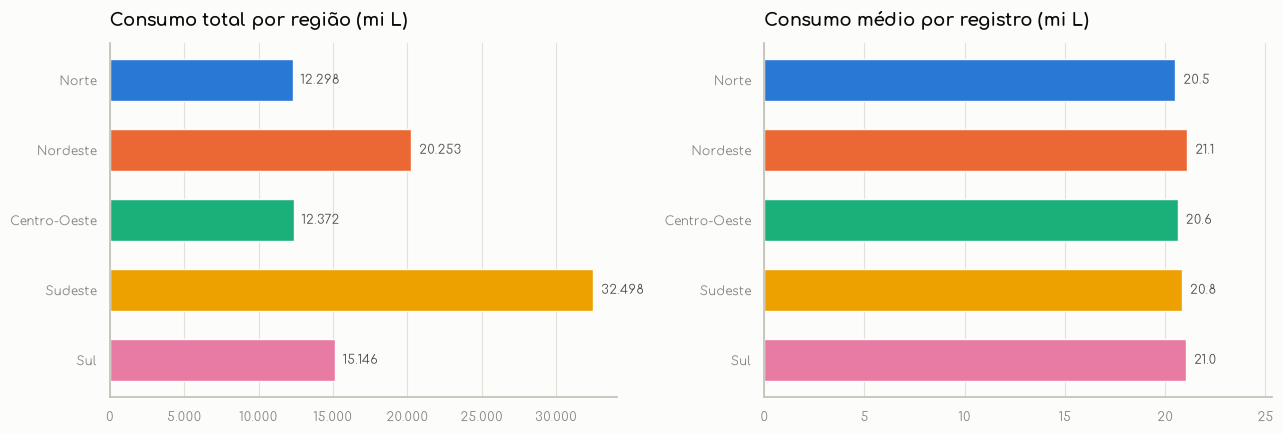

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
reg = df.groupby("regiao", observed=True)["consumo_milhoes_litros"].sum()
ax1.barh(reg.index.astype(str)[::-1], reg.values[::-1],
         color=[estilo.CORES_REGIAO[r] for r in reg.index.astype(str)[::-1]], height=0.6)
ax1.set_title("Consumo total por região (mi L)")
ax1.xaxis.set_major_formatter(FuncFormatter(estilo.fmt_milhar))
for i, v in enumerate(reg.values[::-1]):
    ax1.text(v, i, f"  {estilo.fmt_milhar(v)}", va="center", fontsize=9, color=estilo.TINTA_SEC)

media_reg = df.groupby("regiao", observed=True)["consumo_milhoes_litros"].mean()
ax2.barh(media_reg.index.astype(str)[::-1], media_reg.values[::-1],
         color=[estilo.CORES_REGIAO[r] for r in media_reg.index.astype(str)[::-1]], height=0.6)
ax2.set_title("Consumo médio por registro (mi L)")
ax2.set_xlim(0, media_reg.max() * 1.2)
for i, v in enumerate(media_reg.values[::-1]):
    ax2.text(v, i, f"  {v:.1f}", va="center", fontsize=9, color=estilo.TINTA_SEC)
for ax in (ax1, ax2):
    ax.grid(axis="y", visible=False)
fig.tight_layout()
salvar(fig, "01_consumo_regiao")
plt.show()

À esquerda, o total sugere que o Sudeste "consome mais". À direita, normalizado por registro, o consumo é **igual em todas
as regiões** (~21 mi L). Comparar totais de grupos com tamanhos diferentes engana.

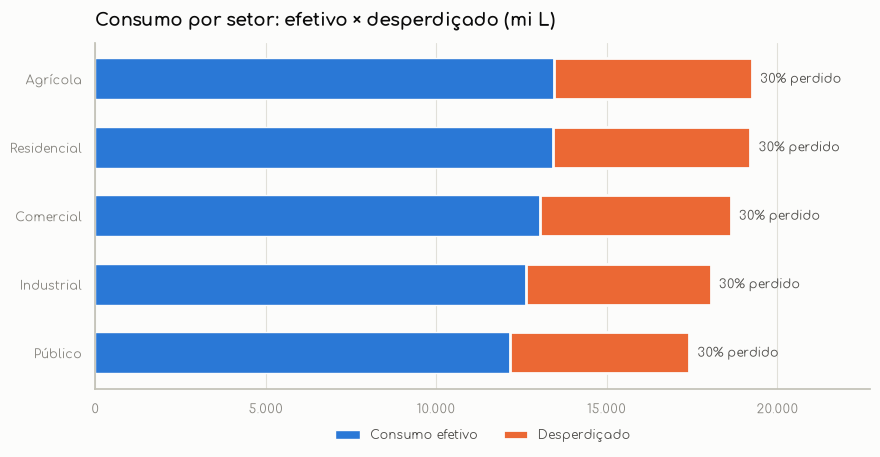

In [23]:
fig, ax = plt.subplots(figsize=(10, 4.5))
setor = (df.groupby("setor_consumo", observed=True)
           .agg(efetivo=("consumo_efetivo_ml", "sum"), desperdicado=("volume_desperdicado_ml", "sum"))
           .sort_values("efetivo"))
y = np.arange(len(setor))
ax.barh(y, setor["efetivo"], color=estilo.PRIMARIA, height=0.6, label="Consumo efetivo")
ax.barh(y, setor["desperdicado"], left=setor["efetivo"], color=estilo.CATEGORICA[1], height=0.6,
        label="Desperdiçado", edgecolor=estilo.SUPERFICIE, linewidth=2)
ax.set_yticks(y, setor.index.astype(str))
for i, (e, d) in enumerate(zip(setor["efetivo"], setor["desperdicado"])):
    ax.text(e + d, i, f"  {d / (e + d):.0%} perdido", va="center", fontsize=9, color=estilo.TINTA_SEC)
ax.set_xlim(0, (setor.sum(axis=1)).max() * 1.18)
ax.xaxis.set_major_formatter(FuncFormatter(estilo.fmt_milhar))
ax.set_title("Consumo por setor: efetivo × desperdiçado (mi L)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncols=2)
ax.grid(axis="y", visible=False)
salvar(fig, "02_desperdicio_setor")
plt.show()

### 9.2 Evolução temporal

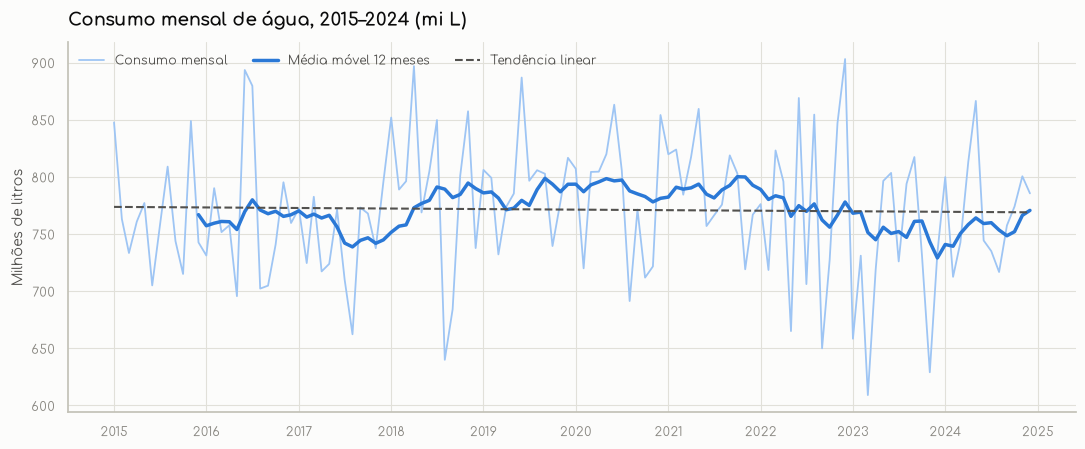

In [24]:
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(mensal.index, mensal["consumo"], color="#9ec5f4", linewidth=1.3, label="Consumo mensal")
ax.plot(mensal.index, mensal["consumo_mm12"], color=estilo.PRIMARIA, linewidth=2.5, label="Média móvel 12 meses")
ax.plot(mensal.index, mensal["consumo_tendencia"], color=estilo.TINTA_SEC, linewidth=1.5, linestyle="--",
        label="Tendência linear")
ax.set_title("Consumo mensal de água, 2015–2024 (mi L)")
ax.set_ylabel("Milhões de litros")
ax.legend(loc="upper left", ncols=3)
salvar(fig, "03_serie_temporal")
plt.show()

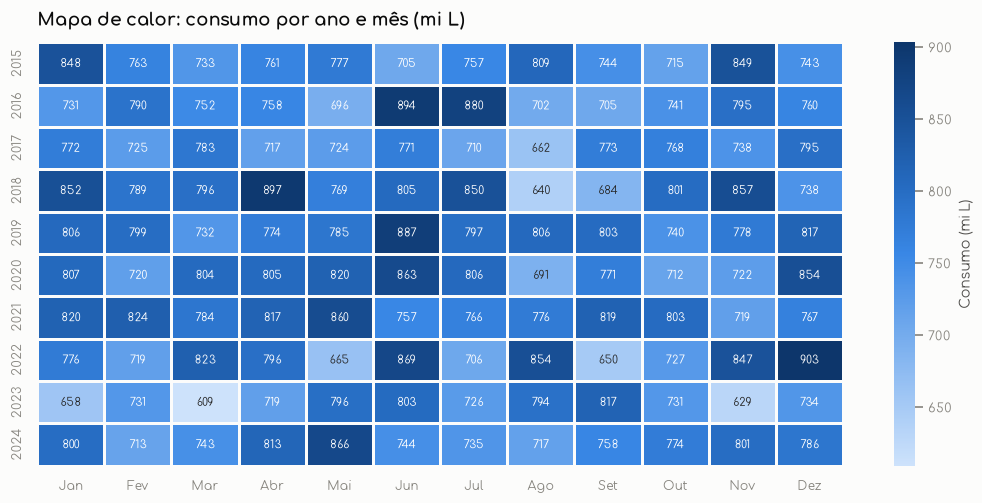

In [25]:
pivo = df.pivot_table(index="ano", columns="mes", values="consumo_milhoes_litros", aggfunc="sum")
pivo.columns = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(pivo, cmap=estilo.CMAP_SEQ, annot=True, fmt=".0f", linewidths=2, linecolor=estilo.SUPERFICIE,
            cbar_kws={"label": "Consumo (mi L)"}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Mapa de calor: consumo por ano e mês (mi L)")
ax.set_xlabel("")
ax.set_ylabel("")
salvar(fig, "04_heatmap_ano_mes")
plt.show()

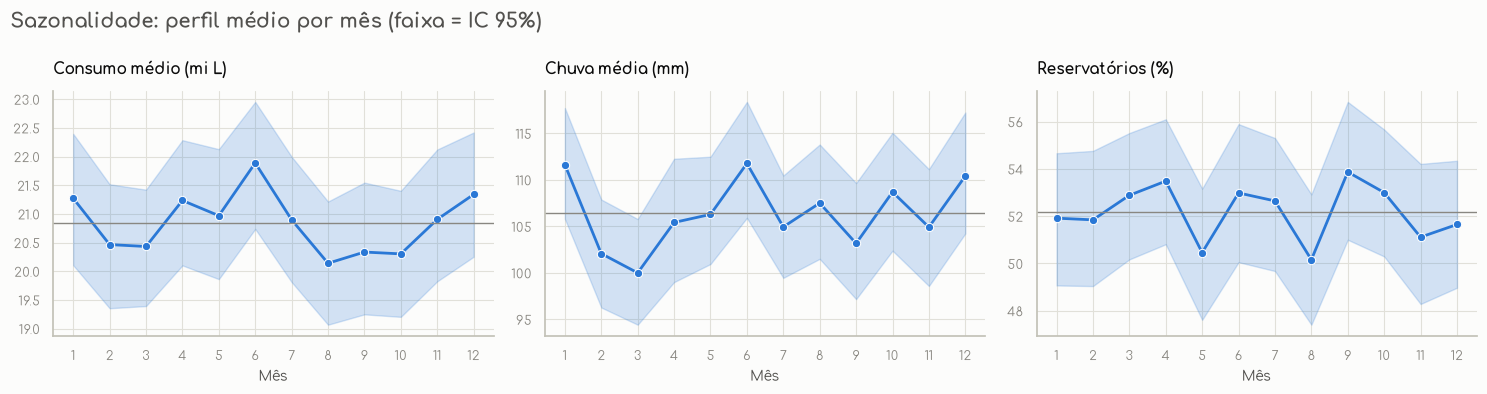

In [26]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, (col, titulo) in zip(eixos, [("consumo_milhoes_litros", "Consumo médio (mi L)"),
                                     ("chuva_mm", "Chuva média (mm)"),
                                     ("reservatorios_percentual", "Reservatórios (%)")]):
    sns.lineplot(data=df, x="mes", y=col, errorbar=("ci", 95), marker="o", color=estilo.PRIMARIA, ax=ax)
    ax.axhline(df[col].mean(), color=estilo.TINTA_MUTED, linewidth=1)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("Mês")
    ax.set_ylabel("")
    ax.set_xticks(range(1, 13))
fig.suptitle("Sazonalidade: perfil médio por mês (faixa = IC 95%)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
salvar(fig, "05_sazonalidade")
plt.show()

### 9.3 Distribuições

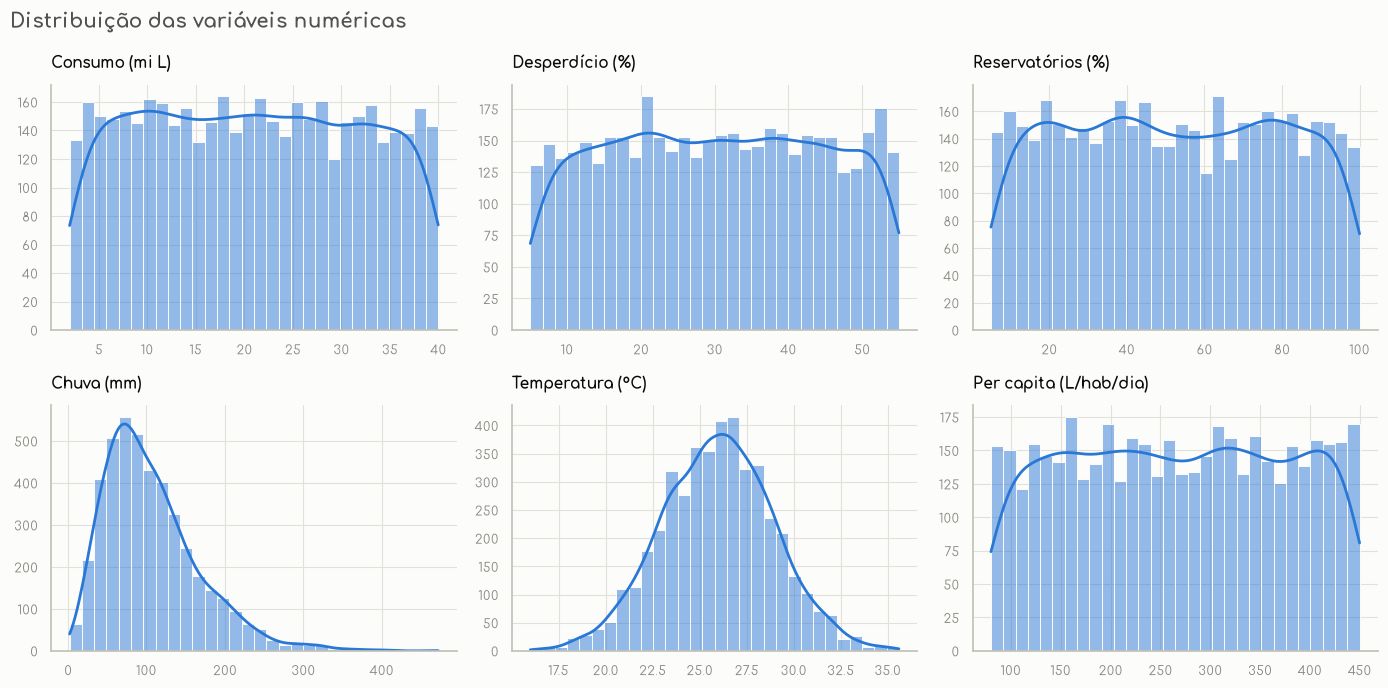

In [27]:
fig, eixos = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(eixos.flat, ["consumo_milhoes_litros", "desperdicio_percentual", "reservatorios_percentual",
                                "chuva_mm", "temperatura_media", "consumo_per_capita"]):
    sns.histplot(df[col], bins=30, kde=True, color=estilo.PRIMARIA, edgecolor=estilo.SUPERFICIE, ax=ax)
    ax.set_title(dados.ROTULOS[col], fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Distribuição das variáveis numéricas", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
salvar(fig, "06_distribuicoes")
plt.show()

### 9.4 Correlação entre variáveis

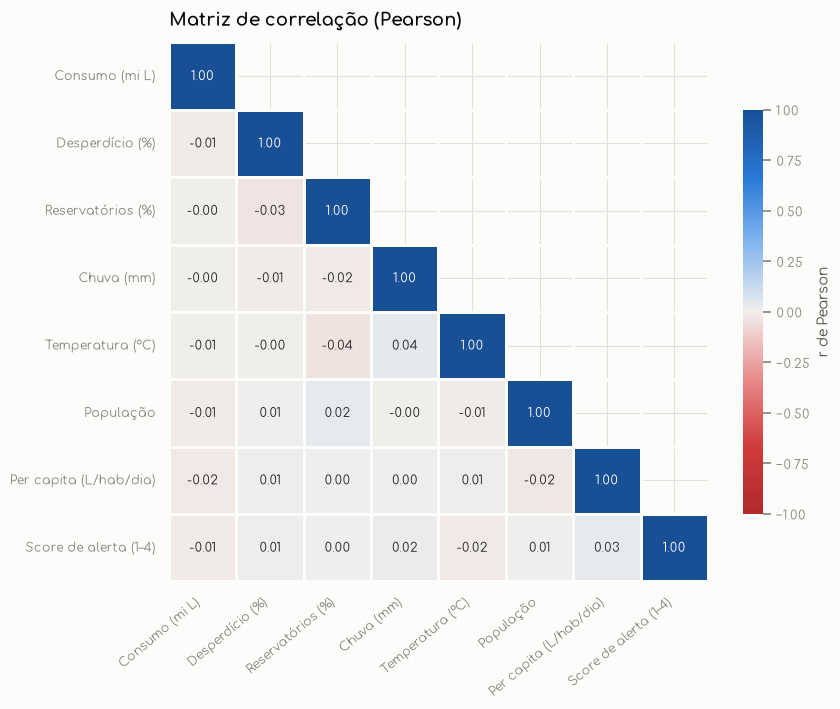

Maior |r|: 0.043 · limite de significância (5%): ±0.029


In [28]:
vars_corr = num + ["score_alerta"]
corr = df[vars_corr].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), cmap=estilo.CMAP_DIV, vmin=-1, vmax=1,
            center=0, annot=True, fmt=".2f", linewidths=2, linecolor=estilo.SUPERFICIE, square=True,
            xticklabels=[dados.ROTULOS[c] for c in vars_corr], yticklabels=[dados.ROTULOS[c] for c in vars_corr],
            cbar_kws={"shrink": 0.75, "label": "r de Pearson"}, annot_kws={"size": 9}, ax=ax)
ax.set_title("Matriz de correlação (Pearson)")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
salvar(fig, "07_correlacao")
plt.show()

limite = 1.96 / np.sqrt(len(df))
pares = corr.where(np.tril(np.ones_like(corr, dtype=bool), k=-1)).stack().dropna()
print(f"Maior |r|: {pares.abs().max():.3f} · limite de significância (5%): ±{limite:.3f}")

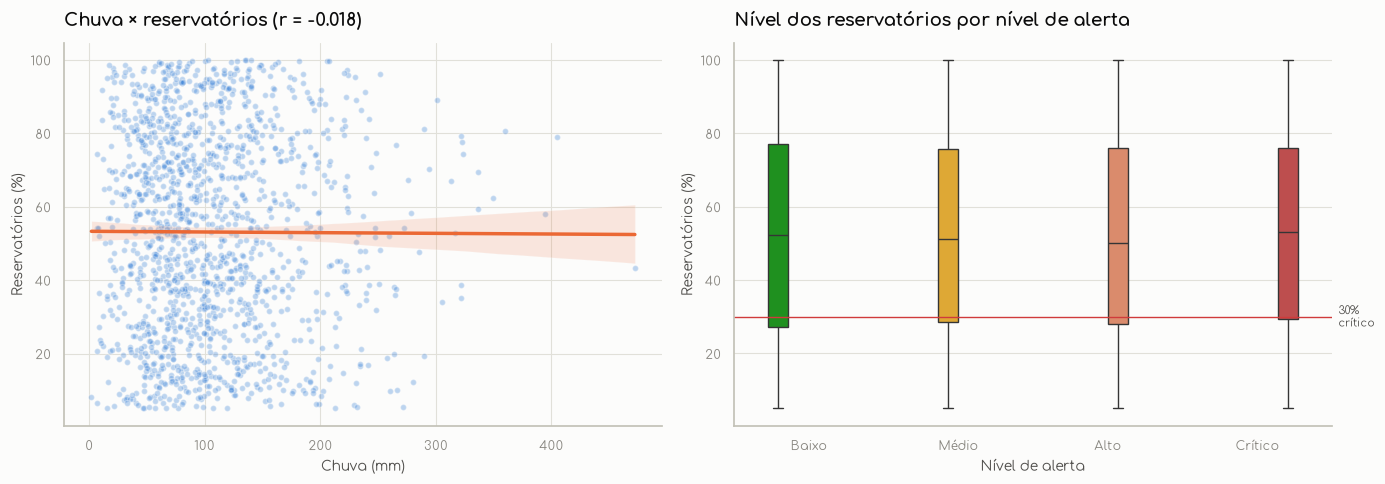

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
amostra = df.sample(1500, random_state=42)
sns.regplot(data=amostra, x="chuva_mm", y="reservatorios_percentual", ax=ax1,
            scatter_kws=dict(alpha=0.3, s=18, color=estilo.PRIMARIA, edgecolor=estilo.SUPERFICIE),
            line_kws=dict(color=estilo.CATEGORICA[1], linewidth=2.5))
r = df["chuva_mm"].corr(df["reservatorios_percentual"])
ax1.set_title(f"Chuva × reservatórios (r = {r:+.3f})")
ax1.set_xlabel("Chuva (mm)")
ax1.set_ylabel("Reservatórios (%)")

sns.boxplot(data=df, x="nivel_alerta", y="reservatorios_percentual", hue="nivel_alerta",
            palette=estilo.CORES_ALERTA, legend=False, width=0.55, ax=ax2)
ax2.axhline(30, color=estilo.CORES_ALERTA["Crítico"], linewidth=1)
ax2.text(1.01, 30, "30%\ncrítico", transform=ax2.get_yaxis_transform(), va="center", fontsize=8,
         color=estilo.TINTA_SEC)
ax2.set_title("Nível dos reservatórios por nível de alerta")
ax2.set_xlabel("Nível de alerta")
ax2.set_ylabel("Reservatórios (%)")
fig.tight_layout()
salvar(fig, "08_chuva_alerta_reservatorio")
plt.show()

### 9.5 Integração com o IBGE: população da base × oficial

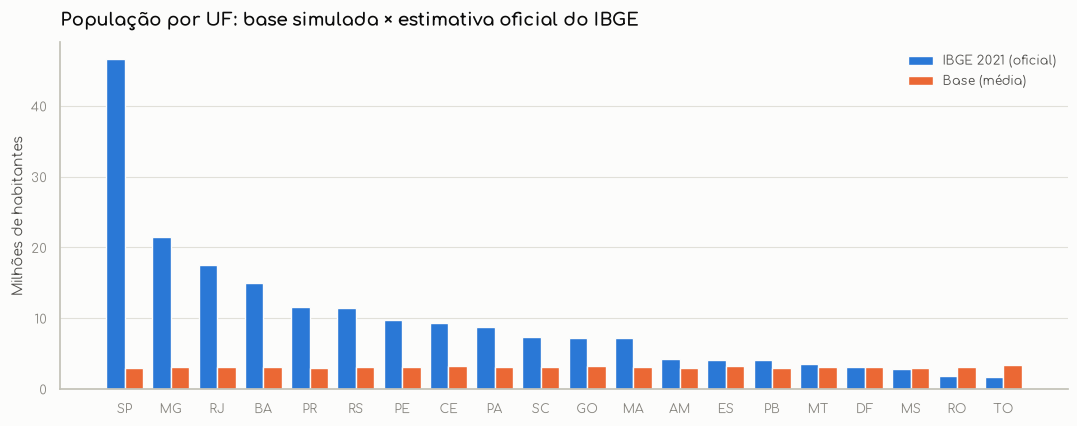

In [30]:
p = pop.sort_values("populacao_ibge", ascending=False)
x = np.arange(len(p))
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(x - 0.2, p["populacao_ibge"] / 1e6, width=0.4, color=estilo.PRIMARIA, label="IBGE 2021 (oficial)")
ax.bar(x + 0.2, p["pop_base_media"] / 1e6, width=0.4, color=estilo.CATEGORICA[1], label="Base (média)")
ax.set_xticks(x, p.index)
ax.set_ylabel("Milhões de habitantes")
ax.set_title("População por UF: base simulada × estimativa oficial do IBGE")
ax.legend()
ax.grid(axis="x", visible=False)
salvar(fig, "09_populacao_ibge")
plt.show()

## 10. Interpretação dos resultados

| Pergunta | Resposta |
|---|---|
| Onde se concentra o consumo? | Sudeste (35%) e Nordeste (22%) lideram o total, mas só porque têm mais séries. Por registro, todas as regiões consomem ~21 mi L/mês. |
| Qual setor consome mais? | Nenhum se destaca: os 5 setores ficam entre 19% e 21% do consumo. |
| Qual o tamanho do desperdício? | **30,1%** do volume (27,9 bilhões de litros), uniforme entre setores (30,0%–30,5%) e regiões (29,4%–30,5%). |
| Como estão os reservatórios? | Nível médio de 52%. **26,8%** dos registros estão abaixo de 30% e **50,7%** em alerta Alto ou Crítico. |
| Há tendência? | Não. A inclinação é de −0,48 mi L/ano (−0,06% do consumo mensal), e as variações anuais oscilam entre −6,3% e +6,0% sem padrão. |
| Há sazonalidade? | Não. Consumo, chuva e reservatórios têm perfil mensal plano, com ICs de 95% sobrepostos. Nem a chuva tem estação chuvosa (106 mm em média tanto no período chuvoso quanto na estiagem). |
| O clima explica o consumo? | Não. A maior correlação da matriz é \|r\| = 0,043 (temperatura × reservatórios), o que explica menos de 0,2% da variância. |
| Os dados são consistentes? | **Não.** 0 de 5 testes de coerência passaram: alerta, população e per capita não se relacionam com as variáveis das quais deveriam depender. |

**Leitura crítica:** o resultado mais importante desta análise é **metodológico**. Uma EDA bem feita não procura só
padrões: ela também **confirma se os padrões esperados existem**. Aqui a ausência de relações reais (chuva → reservatório,
alerta → reservatório) mostra que a base é sintética. Os KPIs descritivos funcionam como exercício, mas conclusões
causais ou preditivas não seriam válidas.

## 11. Conclusão

1. **O desperdício (~30%) é o principal problema e é sistêmico.** Ele atinge igualmente todas as regiões e setores, o que
   pede ações estruturais (redução de perdas na rede) e não campanhas focadas em um setor.
2. **A segurança hídrica pede monitoramento:** 1 em cada 4 registros tem reservatório crítico (< 30%).
3. **Consumo estável e sem sazonalidade:** a base não mostra crescimento de demanda.
4. **Comparações justas exigem normalização:** o total por região reflete o número de séries, não a intensidade de uso.
5. **Qualidade de dados é pré-requisito:** a auditoria encontrou inconsistências que tornariam qualquer modelo preditivo
   inválido. A recomendação é **recalcular o nível de alerta** com regras objetivas e **validar a população com o IBGE**
   na origem.

**Próximos passos:** aplicar o mesmo pipeline (já preparado para receber outra base por upload no dashboard) a dados
oficiais do **SNIS** e da **ANA**, em que as relações clima × reservatório × consumo podem ser medidas de verdade.

O dashboard interativo (Streamlit) traz estas análises com filtros, mapa e consultas SQL.